# DCGAN Baseline

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display

from src.utils.paths import load_config, ensure_dir

In [2]:
config = load_config(PROJECT_ROOT / "config.yaml")

figures_dir = ensure_dir(PROJECT_ROOT / config["reports"]["figures_dir"])

dcgan_log_path = PROJECT_ROOT / "runs" / "dcgan" / "training_log.csv"
dcgan_samples_path = PROJECT_ROOT / "reports" / "figures" / "dcgan_samples_grid.png"
dcgan_progression_dir = PROJECT_ROOT / "outputs" / "generated_samples" / "dcgan" / "fixed_noise_progression"

vae_samples_path = PROJECT_ROOT / "reports" / "figures" / "vae_samples_grid.png"

print("DCGAN log path:", dcgan_log_path)
print("DCGAN sample grid:", dcgan_samples_path)
print("DCGAN progression folder:", dcgan_progression_dir)

DCGAN log path: e:\celeba-generative-comparison\runs\dcgan\training_log.csv
DCGAN sample grid: e:\celeba-generative-comparison\reports\figures\dcgan_samples_grid.png
DCGAN progression folder: e:\celeba-generative-comparison\outputs\generated_samples\dcgan\fixed_noise_progression


In [3]:
dcgan_log = pd.read_csv(dcgan_log_path)

print("Training log shape:", dcgan_log.shape)
display(dcgan_log.head())
display(dcgan_log.tail())

Training log shape: (30, 9)


,epoch,loss_d,loss_g,d_real,d_fake,instance_noise_std,generator_lr,discriminator_lr,real_label_smooth
0,1,0.406828,1.436052,0.881464,0.021882,0.050000,0.0002,0.0001,0.9
1,2,0.704970,2.006646,0.760218,0.139364,0.048276,0.0002,0.0001,0.9
2,3,0.865974,2.271189,0.684645,0.212809,0.046552,0.0002,0.0001,0.9
3,4,0.810177,1.270350,0.699485,0.199154,0.044828,0.0002,0.0001,0.9
4,5,0.654027,0.636699,0.763702,0.135317,0.043103,0.0002,0.0001,0.9


,epoch,loss_d,loss_g,d_real,d_fake,instance_noise_std,generator_lr,discriminator_lr,real_label_smooth
25,26,0.682224,1.047618,0.757523,0.141458,0.006897,0.0002,0.0001,0.9
26,27,0.651838,1.469956,0.763974,0.135758,0.005172,0.0002,0.0001,0.9
27,28,0.604022,2.272548,0.782335,0.117097,0.003448,0.0002,0.0001,0.9
28,29,0.593923,2.855870,0.792070,0.107506,0.001724,0.0002,0.0001,0.9
29,30,0.538079,3.269669,0.814938,0.084887,0.000000,0.0002,0.0001,0.9


In [4]:
summary_cols = [
    "loss_d",
    "loss_g",
    "d_real",
    "d_fake",
    "instance_noise_std"
]

display(dcgan_log[summary_cols].describe())

,loss_d,loss_g,d_real,d_fake,instance_noise_std
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,0.528317,0.961481,0.824564,0.075307,0.025000
std,0.125578,0.799929,0.054070,0.053449,0.015178
min,0.382072,0.388062,0.684645,0.017881,0.000000
25%,0.436827,0.448030,0.784769,0.034815,0.012500
50%,0.487564,0.527795,0.843572,0.056136,0.025000
75%,0.601497,1.214667,0.865137,0.114699,0.037500
max,0.865974,3.269669,0.882291,0.212809,0.050000


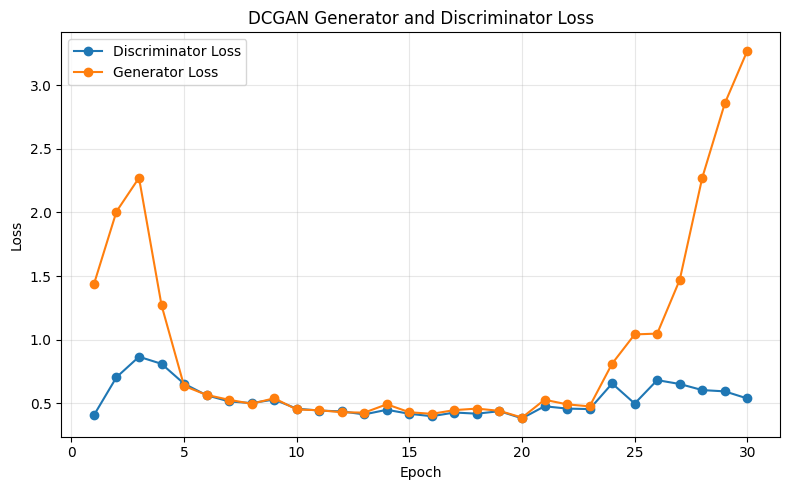

Saved to: e:\celeba-generative-comparison\reports\figures\dcgan_loss_curve.png


In [5]:
plt.figure(figsize=(8, 5))

plt.plot(dcgan_log["epoch"], dcgan_log["loss_d"], marker="o", label="Discriminator Loss")
plt.plot(dcgan_log["epoch"], dcgan_log["loss_g"], marker="o", label="Generator Loss")

plt.title("DCGAN Generator and Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_curve_path = figures_dir / "dcgan_loss_curve.png"
plt.savefig(loss_curve_path, dpi=150)
plt.show()

print("Saved to:", loss_curve_path)

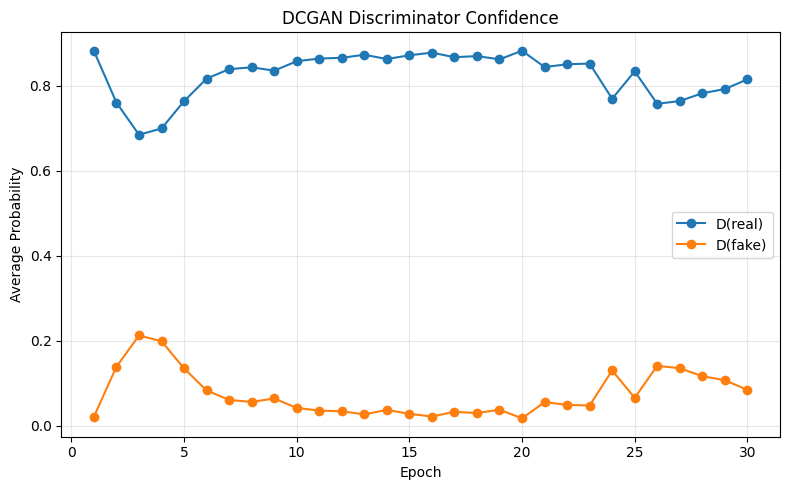

Saved to: e:\celeba-generative-comparison\reports\figures\dcgan_discriminator_confidence.png


In [6]:
plt.figure(figsize=(8, 5))

plt.plot(dcgan_log["epoch"], dcgan_log["d_real"], marker="o", label="D(real)")
plt.plot(dcgan_log["epoch"], dcgan_log["d_fake"], marker="o", label="D(fake)")

plt.title("DCGAN Discriminator Confidence")
plt.xlabel("Epoch")
plt.ylabel("Average Probability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

confidence_curve_path = figures_dir / "dcgan_discriminator_confidence.png"
plt.savefig(confidence_curve_path, dpi=150)
plt.show()

print("Saved to:", confidence_curve_path)

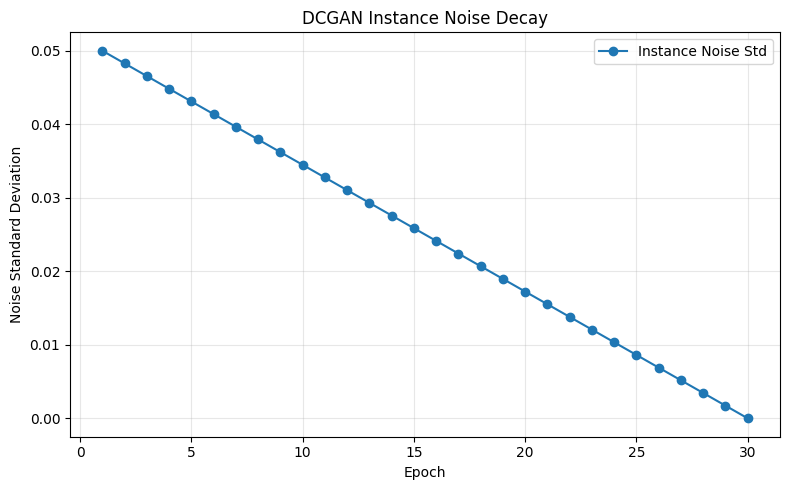

Saved to: e:\celeba-generative-comparison\reports\figures\dcgan_instance_noise_curve.png


In [7]:
if "instance_noise_std" in dcgan_log.columns:
    plt.figure(figsize=(8, 5))

    plt.plot(
        dcgan_log["epoch"],
        dcgan_log["instance_noise_std"],
        marker="o",
        label="Instance Noise Std"
    )

    plt.title("DCGAN Instance Noise Decay")
    plt.xlabel("Epoch")
    plt.ylabel("Noise Standard Deviation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    noise_curve_path = figures_dir / "dcgan_instance_noise_curve.png"
    plt.savefig(noise_curve_path, dpi=150)
    plt.show()

    print("Saved to:", noise_curve_path)
else:
    print("No instance_noise_std column found.")

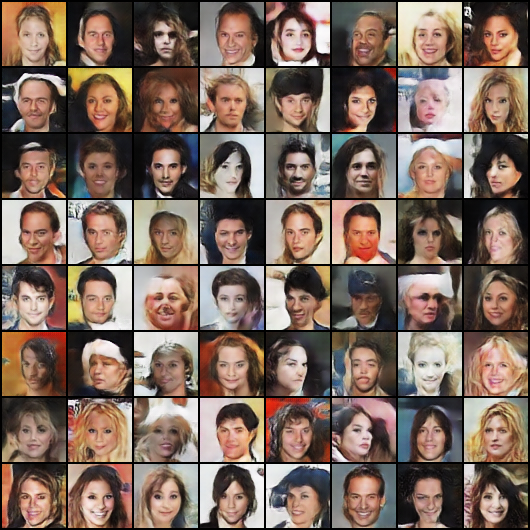

In [9]:
if dcgan_samples_path.exists():
    display(Image.open(dcgan_samples_path))
else:
    print("DCGAN sample grid not found:", dcgan_samples_path)

VAE Generated Samples


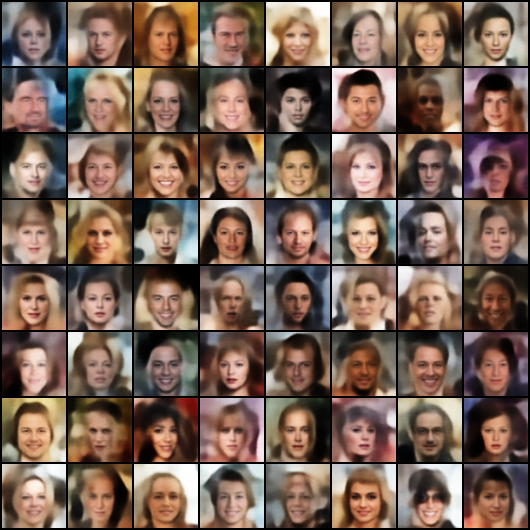

DCGAN Generated Samples


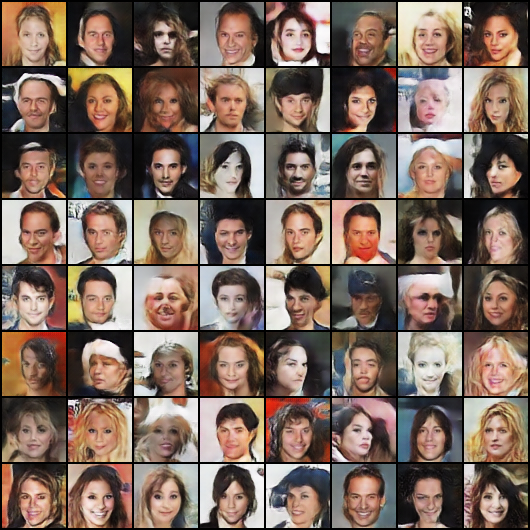

In [12]:
if vae_samples_path.exists():
    print("VAE Generated Samples")
    display(Image.open(vae_samples_path))
else:
    print("VAE sample grid not found:", vae_samples_path)

if dcgan_samples_path.exists():
    print("DCGAN Generated Samples")
    display(Image.open(dcgan_samples_path))
else:
    print("DCGAN sample grid not found:", dcgan_samples_path)

## DCGAN Baseline Summary

The tuned DCGAN successfully generated face-like images from random noise. Compared with the VAE baseline, the DCGAN produced sharper and more detailed outputs, with clearer hair regions, face outlines, and visual texture.

The tuned stabilisation strategy improved the result compared with the first DCGAN run. One-sided label smoothing, a lower discriminator learning rate, and instance noise helped reduce discriminator dominance and improved sample diversity.

However, the DCGAN still showed typical adversarial training limitations. The generator and discriminator losses were less smooth than the VAE loss curves, and some generated samples contained visual artifacts or distorted facial features.

This makes the DCGAN a useful second baseline before moving to the main diffusion model.